# Air Quality Time-Series Dataset — Exploratory Data Analysis & Feature Engineering

**Assignment:** Dataset Exploration for Neural Network Implementation (Part 1 — EDA & Feature Engineering)

**Dataset:** Kathmandu Air Quality (PM2.5 & Ozone) — US Diplomatic Post: Embassy Kathmandu
**Source:** OpenAQ — U.S. Department of State AirNow monitoring network
**Period covered:** March 2017 – March 2021 (hourly observations)

---

## 1. Introduction and Dataset Description

Air pollution is one of the most pressing public-health and environmental problems facing South Asian cities, and Kathmandu regularly records some of the worst air quality in the world. This dataset contains **hourly measurements of two criteria pollutants — PM2.5 (fine particulate matter, µg/m³) and Ground-level Ozone (O3, ppm)** — recorded by the U.S. Embassy's air-quality monitoring station in Kathmandu, Nepal, between March 2017 and March 2021.

**Why this dataset is suitable for a neural network assignment:** it is a real-world, moderately noisy, univariate/multivariate **time series**, which makes it an ideal candidate for sequence-based deep learning models such as **LSTM / GRU / 1-D CNN networks** in the follow-up assignment, where the task will be to **forecast future PM2.5 concentration** (regression) and/or **classify the resulting Air Quality Index category** (classification) from historical readings.

This notebook performs the exploratory data analysis (EDA) and feature engineering that will feed that upcoming neural network implementation.


In [6]:
# Core libraries for EDA, visualization and feature engineering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries loaded successfully.")
print("pandas:", pd.__version__, "| numpy:", np.__version__)


Libraries loaded successfully.
pandas: 2.2.2 | numpy: 2.0.2


## 3. Loading the Dataset


In [7]:
# Loading the Dataset
import pandas as pd

# Loading the Dataset
DATA_PATH = "/content/tmpv4ryiymi.csv"

df_raw = pd.read_csv(DATA_PATH)

# Display first few rows
print(df_raw.head())

   locationId                               location       city country                        utc                      local parameter  \
0        3459  US Diplomatic Post: Embassy Kathmandu  Kathmandu      NP  2021-03-12T18:15:00+00:00  2021-03-13T00:00:00+05:45        o3   
1        3459  US Diplomatic Post: Embassy Kathmandu  Kathmandu      NP  2021-03-12T18:15:00+00:00  2021-03-13T00:00:00+05:45      pm25   
2        3459  US Diplomatic Post: Embassy Kathmandu  Kathmandu      NP  2021-03-12T17:15:00+00:00  2021-03-12T23:00:00+05:45      pm25   
3        3459  US Diplomatic Post: Embassy Kathmandu  Kathmandu      NP  2021-03-12T17:15:00+00:00  2021-03-12T23:00:00+05:45        o3   
4        3459  US Diplomatic Post: Embassy Kathmandu  Kathmandu      NP  2021-03-12T16:15:00+00:00  2021-03-12T22:00:00+05:45      pm25   

    value   unit   latitude  longitude  
0   0.057    ppm  27.738703  85.336205  
1  50.000  µg/m³  27.738703  85.336205  
2  46.000  µg/m³  27.738703  85.336205  
3

## 4. Initial Data Inspection

In [8]:
print("First 5 rows:")
print(df_raw.head().to_string())


First 5 rows:
   locationId                               location       city country                        utc                      local parameter   value   unit   latitude  longitude
0        3459  US Diplomatic Post: Embassy Kathmandu  Kathmandu      NP  2021-03-12T18:15:00+00:00  2021-03-13T00:00:00+05:45        o3   0.057    ppm  27.738703  85.336205
1        3459  US Diplomatic Post: Embassy Kathmandu  Kathmandu      NP  2021-03-12T18:15:00+00:00  2021-03-13T00:00:00+05:45      pm25  50.000  µg/m³  27.738703  85.336205
2        3459  US Diplomatic Post: Embassy Kathmandu  Kathmandu      NP  2021-03-12T17:15:00+00:00  2021-03-12T23:00:00+05:45      pm25  46.000  µg/m³  27.738703  85.336205
3        3459  US Diplomatic Post: Embassy Kathmandu  Kathmandu      NP  2021-03-12T17:15:00+00:00  2021-03-12T23:00:00+05:45        o3   0.051    ppm  27.738703  85.336205
4        3459  US Diplomatic Post: Embassy Kathmandu  Kathmandu      NP  2021-03-12T16:15:00+00:00  2021-03-12T22:00:00+0

In [9]:
print("Column data types:")
print(df_raw.dtypes)
print()
print("Shape:", df_raw.shape)


Column data types:
locationId      int64
location       object
city           object
country        object
utc            object
local          object
parameter      object
value         float64
unit           object
latitude      float64
longitude     float64
dtype: object

Shape: (60779, 11)


In [10]:
print("Missing values per column:")
print(df_raw.isna().sum())
print()
print("Duplicate rows:", df_raw.duplicated().sum())


Missing values per column:
locationId    0
location      0
city          0
country       0
utc           0
local         0
parameter     0
value         0
unit          0
latitude      0
longitude     0
dtype: int64

Duplicate rows: 0


In [11]:
print("Unique stations / cities:", df_raw['location'].unique())
print("Countries:", df_raw['country'].unique())
print("Pollutants measured:", df_raw['parameter'].unique())
print("Units used:", df_raw['unit'].unique())
print()
print("Local time range:", df_raw['local'].min(), "  to  ", df_raw['local'].max())
print()
print("Row count per pollutant:")
print(df_raw['parameter'].value_counts())


Unique stations / cities: ['US Diplomatic Post: Embassy Kathmandu']
Countries: ['NP']
Pollutants measured: ['o3' 'pm25']
Units used: ['ppm' 'µg/m³']

Local time range: 2017-03-03T05:00:00+05:45   to   2021-03-13T00:00:00+05:45

Row count per pollutant:
parameter
pm25    31378
o3      29401
Name: count, dtype: int64


**Observations so far:**
- The dataset has **no NaN values and no duplicate rows** in its raw long format.
- All readings come from a **single station** (US Embassy Kathmandu), which keeps the series spatially consistent — no need to handle multiple sites.
- Two pollutants are recorded: **PM2.5** (~31.4k readings) and **O3** (~29.4k readings), each roughly hourly, spanning about **4 years** (Mar 2017 – Mar 2021).
- Because pm25 and o3 are stored as separate rows for the same timestamp, the data needs to be **pivoted into a wide format** (one column per pollutant) before it can be used for time-series modelling.

Before trusting the numbers, though, we should always check the **value range** of a sensor reading — "no NaNs" does not mean "no invalid data".


In [12]:
print("Value range per pollutant (BEFORE cleaning):")
print(df_raw.groupby('parameter')['value'].agg(['min', 'max', 'mean']).round(3))
print()
neg_pm25 = ((df_raw['parameter'] == 'pm25') & (df_raw['value'] < 0)).sum()
neg_o3   = ((df_raw['parameter'] == 'o3')   & (df_raw['value'] < 0)).sum()
print(f"Negative PM2.5 readings: {neg_pm25}  (physically impossible - PM2.5 cannot be negative)")
print(f"Negative O3 readings:    {neg_o3}  (physically impossible - O3 cannot be negative)")
print()
print("Most common negative values (top 8 each):")
print("PM2.5:", df_raw.loc[(df_raw['parameter']=='pm25') & (df_raw['value']<0), 'value'].value_counts().head(8).to_dict())
print("O3:   ", df_raw.loc[(df_raw['parameter']=='o3') & (df_raw['value']<0), 'value'].value_counts().head(8).to_dict())


Value range per pollutant (BEFORE cleaning):
               min      max    mean
parameter                          
o3          -0.999    0.174  -0.018
pm25      -999.000  985.000 -67.079

Negative PM2.5 readings: 3561  (physically impossible - PM2.5 cannot be negative)
Negative O3 readings:    1345  (physically impossible - O3 cannot be negative)

Most common negative values (top 8 each):
PM2.5: {-999.0: 3383, -1.0: 68, -2.0: 44, -3.0: 29, -15.0: 17, -4.0: 15, -5.0: 3, -6.0: 2}
O3:    {-0.999: 1293, -0.001: 48, -0.003: 2, -0.002: 1, -0.005: 1}


**Critical data-quality finding:** both pollutants contain a **sentinel "missing reading" code** — `-999` µg/m³ for PM2.5 and `-0.999` ppm for O3 — which is a common convention in AirNow/OpenAQ exports to flag a sensor fault or a calibration/maintenance window, *not* an actual measurement. There is also a smaller number of near-zero negative values (e.g. -1, -2, -3 µg/m³), which are typical **electronic/calibration noise** around a true value close to 0 rather than sentinel codes. If these were left untouched, the sentinel values alone would drag the PM2.5 mean from a plausible ~40 µg/m³ down to a nonsensical negative number, and every plot/statistic downstream would be wrong. Both issues are fixed in the cleaning step below **before** pivoting the data.


## 5. Data Cleaning & Reshaping

We convert the `local` column to a proper `datetime`, drop the columns that carry no information for modelling (constant across the whole file), and pivot the table so that each row represents **one hourly timestamp** with **pm25** and **o3** as separate feature columns.


In [13]:
df = df_raw.copy()
df['local'] = pd.to_datetime(df['local'], utc=False)
df['utc'] = pd.to_datetime(df['utc'], utc=True)

# --- Fix the sentinel / invalid values found in Section 4 ---
# 1) -999 (pm25) and -0.999 (o3) are explicit "sensor fault / no reading" codes -> treat as missing
is_pm25 = df['parameter'] == 'pm25'
is_o3 = df['parameter'] == 'o3'
sentinel_mask = (is_pm25 & np.isclose(df['value'], -999)) | (is_o3 & np.isclose(df['value'], -0.999))
n_sentinel = sentinel_mask.sum()
df.loc[sentinel_mask, 'value'] = np.nan

# 2) Remaining small negative values are calibration noise around zero -> clip at 0
#    (a pollutant concentration cannot physically be negative)
neg_mask = df['value'] < 0
n_clipped = neg_mask.sum()
df.loc[neg_mask, 'value'] = 0.0

print(f"Sentinel readings (-999 / -0.999) converted to NaN: {n_sentinel}")
print(f"Remaining small negative readings clipped to 0:     {n_clipped}")
print()
print("Value range per pollutant (AFTER cleaning):")
print(df.groupby('parameter')['value'].agg(['min', 'max', 'mean']).round(3))

# Pivot long -> wide: one row per timestamp, one column per pollutant
wide = df.pivot_table(index='local', columns='parameter', values='value', aggfunc='mean')
wide = wide.sort_index()
wide.columns.name = None
wide = wide.rename(columns={'pm25': 'pm25_ugm3', 'o3': 'o3_ppm'})

print("Wide-format shape:", wide.shape)
print(wide.head().to_string())


Sentinel readings (-999 / -0.999) converted to NaN: 4676
Remaining small negative readings clipped to 0:     230

Value range per pollutant (AFTER cleaning):
           min      max    mean
parameter                      
o3         0.0    0.174   0.027
pm25       0.0  985.000  45.558
Wide-format shape: (29901, 2)
                           o3_ppm  pm25_ugm3
local                                       
2017-03-03 05:00:00+05:45   0.004       54.5
2017-03-03 06:00:00+05:45   0.004       73.3
2017-03-03 07:00:00+05:45   0.003       76.1
2017-03-03 08:00:00+05:45   0.005       95.0
2017-03-03 09:00:00+05:45   0.009      208.5


In [14]:
print("Missing values after pivot (a timestamp may have only one of the two pollutants recorded):")
print(wide.isna().sum())
print()
missing_pct = wide.isna().mean() * 100
print("Missing percentage:")
print(missing_pct.round(2))


Missing values after pivot (a timestamp may have only one of the two pollutants recorded):
o3_ppm       1793
pm25_ugm3    1906
dtype: int64

Missing percentage:
o3_ppm       6.00
pm25_ugm3    6.37
dtype: float64


In [15]:
# Build a complete, regular hourly index over the full observation period and reindex.
full_range = pd.date_range(wide.index.min(), wide.index.max(), freq='h')
wide_full = wide.reindex(full_range)
wide_full.index.name = 'local'

print(f"Regular hourly index would contain {len(full_range)} timestamps.")
print(f"Actual observed timestamps: {len(wide)}  ->  "
      f"{100*len(wide)/len(full_range):.1f}% of all possible hourly slots are present.")
print()
print("Missing values on the regular hourly grid:")
print(wide_full.isna().sum())


Regular hourly index would contain 35300 timestamps.
Actual observed timestamps: 29901  ->  84.7% of all possible hourly slots are present.

Missing values on the regular hourly grid:
o3_ppm       7192
pm25_ugm3    7305
dtype: int64


In [16]:
# Time-based (short) linear interpolation to fill small sensor gaps, capped at 6 consecutive hours.
# Larger gaps are intentionally left as NaN and reported, not silently invented.
wide_clean = wide_full.interpolate(method='time', limit=6, limit_direction='both')

remaining_na = wide_clean.isna().sum()
print("Remaining missing values after time-interpolation (gaps > 6h left untouched):")
print(remaining_na)
print()
print(f"Rows fully usable after interpolation: {wide_clean.dropna().shape[0]} "
      f"({100*wide_clean.dropna().shape[0]/len(wide_clean):.1f}% of the hourly grid)")


Remaining missing values after time-interpolation (gaps > 6h left untouched):
o3_ppm       4161
pm25_ugm3    4083
dtype: int64

Rows fully usable after interpolation: 30277 (85.8% of the hourly grid)


**Data-cleaning decisions (and why):**
1. **Pivoted to wide format** — required so each timestamp is one feature vector `[pm25, o3]`, the format neural sequence models expect.
2. **Reindexed to a perfectly regular hourly grid** — sensor gaps otherwise silently shift the "time step" seen by an RNN/LSTM.
3. **Short gaps (≤ 6 hours) filled by time-based linear interpolation** — physically reasonable for slowly-varying pollutant concentration; **longer gaps are left as NaN** rather than fabricated, and are simply dropped when building supervised windows in Section 7. This avoids injecting misleading trends into the training data.


## 6. Descriptive Statistics

In [17]:
print(wide_clean.describe().round(3).to_string())


          o3_ppm  pm25_ugm3
count  31139.000  31217.000
mean       0.027     45.727
std        0.020     50.196
min        0.000      0.000
25%        0.009     17.000
50%        0.024     34.000
75%        0.041     61.000
max        0.174    985.000


In [18]:
from scipy import stats
for col in ['pm25_ugm3', 'o3_ppm']:
    s = wide_clean[col].dropna()
    print(f"{col}: skewness = {s.skew():.3f}, kurtosis = {s.kurt():.3f}")


pm25_ugm3: skewness = 7.363, kurtosis = 110.041
o3_ppm: skewness = 0.687, kurtosis = -0.070


**Observations:** PM2.5 has a strong **right skew** — most hours have moderate concentration but a heavy tail of very high-pollution hours (typical of Kathmandu's winter smog/haze episodes and brick-kiln/traffic emissions). O3 is comparatively closer to a bell shape but still right-skewed, consistent with photochemical ozone formation peaking on sunny afternoons.


## 7. Visualization

### 7.1 Full time series


FileNotFoundError: [Errno 2] No such file or directory: 'figs/01_full_timeseries.png'

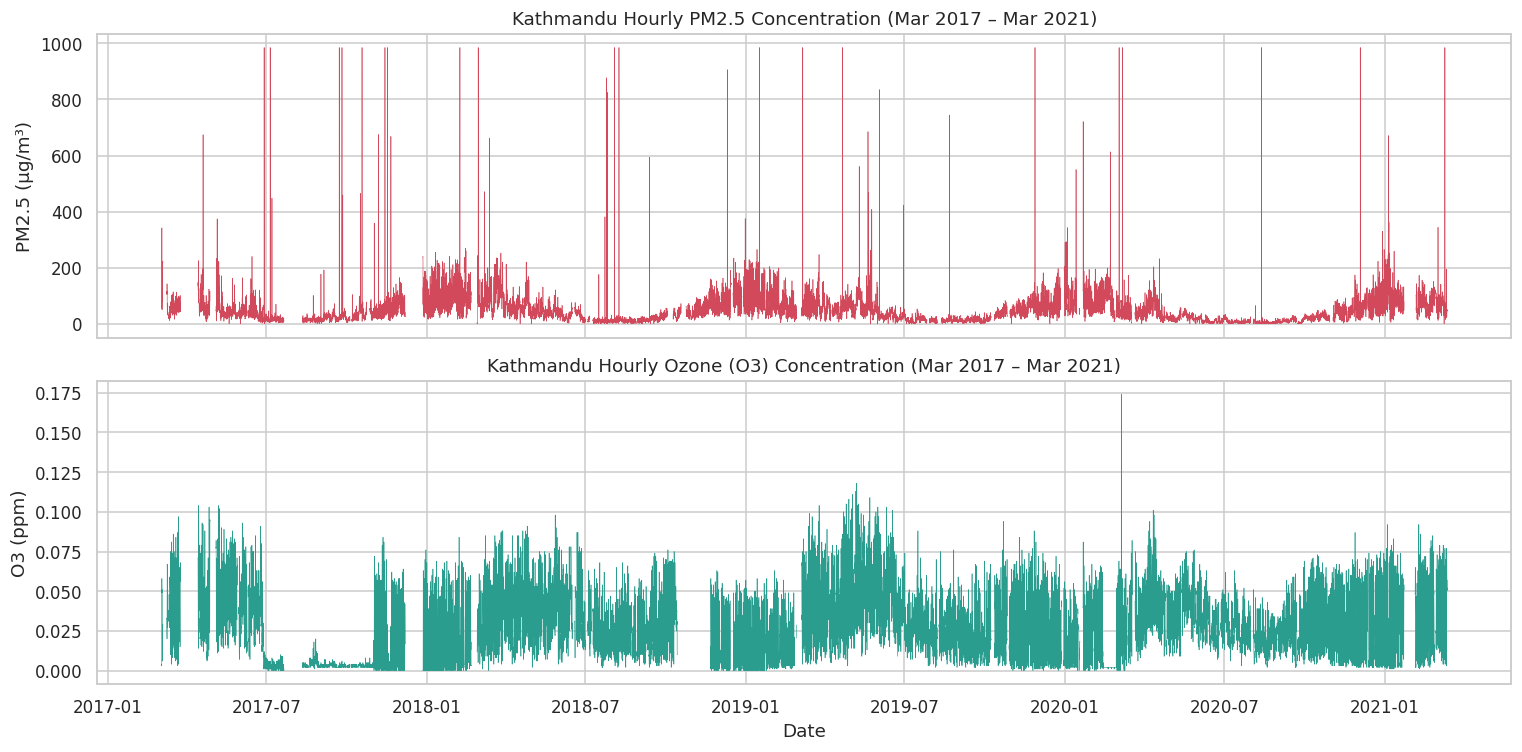

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(wide_clean.index, wide_clean['pm25_ugm3'], color='#d1495b', linewidth=0.4)
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_title('Kathmandu Hourly PM2.5 Concentration (Mar 2017 – Mar 2021)')

axes[1].plot(wide_clean.index, wide_clean['o3_ppm'], color='#2a9d8f', linewidth=0.4)
axes[1].set_ylabel('O3 (ppm)')
axes[1].set_xlabel('Date')
axes[1].set_title('Kathmandu Hourly Ozone (O3) Concentration (Mar 2017 – Mar 2021)')

plt.tight_layout()
plt.savefig('figs/01_full_timeseries.png', dpi=140, bbox_inches='tight')
plt.show()


**Interpretation:** PM2.5 shows a clear **seasonal cycle** — pronounced spikes every winter (Nov–Feb, dry season with temperature inversions and crop-residue burning) and much cleaner air during the monsoon (Jun–Sep, rain washes out particulates). O3 shows the opposite seasonal tendency, peaking in warmer, sunnier months when photochemical reactions are strongest.


### 7.2 Distributions

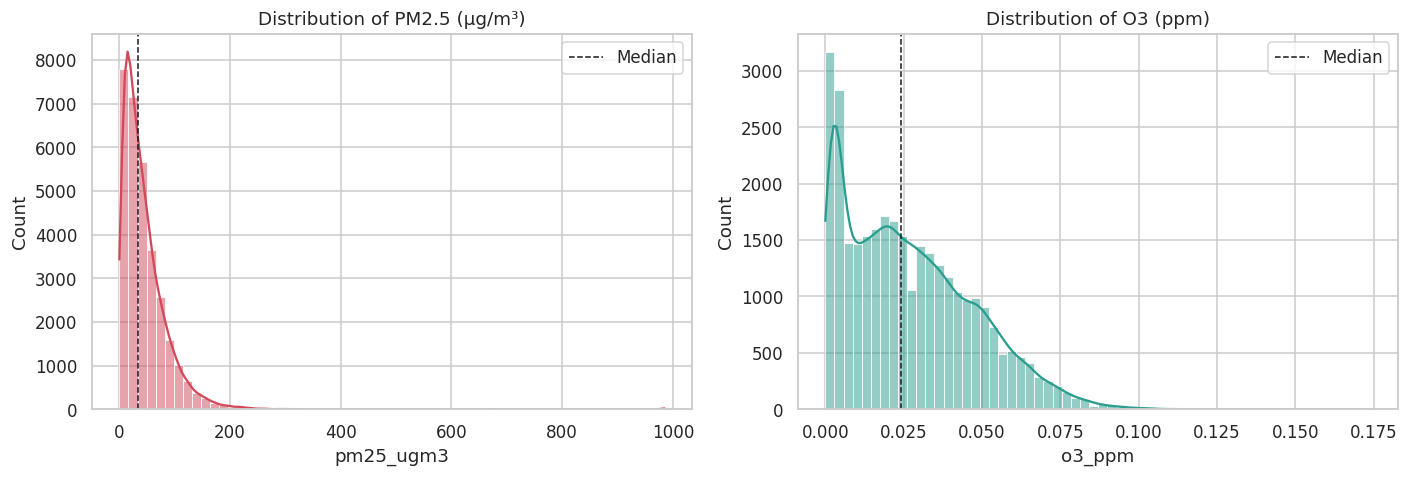

In [21]:
import os

# Create the folder if it doesn't exist
os.makedirs("figs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(wide_clean['pm25_ugm3'].dropna(), bins=60, kde=True,
             ax=axes[0], color='#d1495b')
axes[0].set_title('Distribution of PM2.5 (µg/m³)')
axes[0].axvline(wide_clean['pm25_ugm3'].median(), color='k',
                linestyle='--', linewidth=1, label='Median')
axes[0].legend()

sns.histplot(wide_clean['o3_ppm'].dropna(), bins=60, kde=True,
             ax=axes[1], color='#2a9d8f')
axes[1].set_title('Distribution of O3 (ppm)')
axes[1].axvline(wide_clean['o3_ppm'].median(), color='k',
                linestyle='--', linewidth=1, label='Median')
axes[1].legend()

plt.tight_layout()

# Save the figure
plt.savefig("figs/02_distributions.png", dpi=140, bbox_inches="tight")

plt.show()


### 7.3 Seasonal pattern (monthly boxplot)

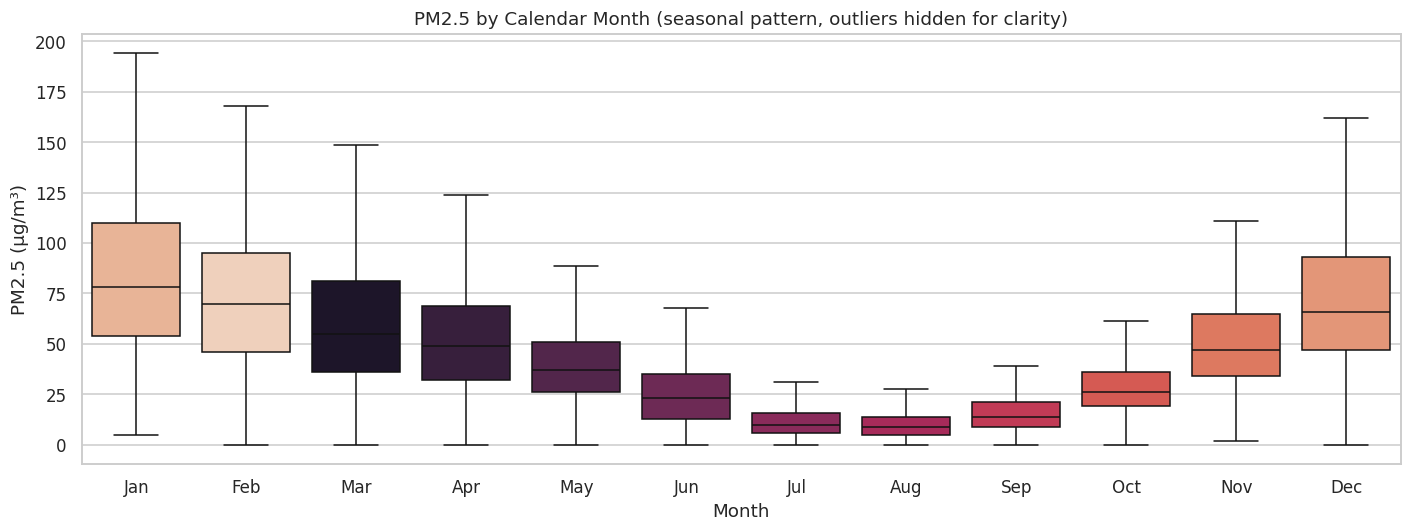

In [26]:
import os
os.makedirs("figs", exist_ok=True)

tmp = wide_clean.copy()
tmp['month'] = tmp.index.month_name().str[:3]

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(13,5))

sns.boxplot(
    data=tmp,
    x='month',
    y='pm25_ugm3',
    hue='month',
    order=month_order,
    palette='rocket',
    showfliers=False,
    legend=False
)

plt.title('PM2.5 by Calendar Month (seasonal pattern, outliers hidden for clarity)')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Month')

plt.tight_layout()
plt.savefig("figs/03_monthly_boxplot.png", dpi=140, bbox_inches="tight")
plt.show()

### 7.4 Diurnal (hour-of-day) pattern

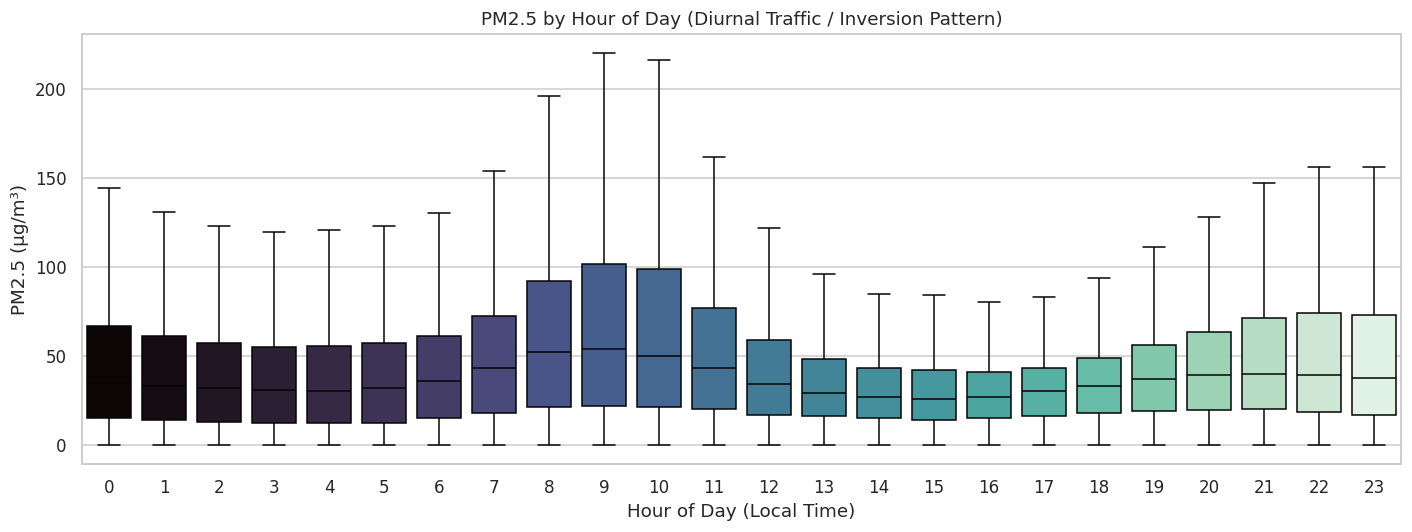

In [28]:
import os
os.makedirs("figs", exist_ok=True)

tmp['hour'] = tmp.index.hour

plt.figure(figsize=(13, 5))

sns.boxplot(
    data=tmp,
    x='hour',
    y='pm25_ugm3',
    hue='hour',
    palette='mako',
    showfliers=False,
    legend=False
)

plt.title('PM2.5 by Hour of Day (Diurnal Traffic / Inversion Pattern)')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Hour of Day (Local Time)')

plt.tight_layout()
plt.savefig("figs/04_hourly_boxplot.png", dpi=140, bbox_inches="tight")
plt.show()


**Interpretation:** PM2.5 peaks in the **early morning (6–9 AM)** and **late evening (7–10 PM)**, coinciding with rush-hour traffic and the evening cooking/heating period combined with a shallower, cooler boundary layer that traps pollutants close to the ground.


### 7.5 Relationship between PM2.5 and O3

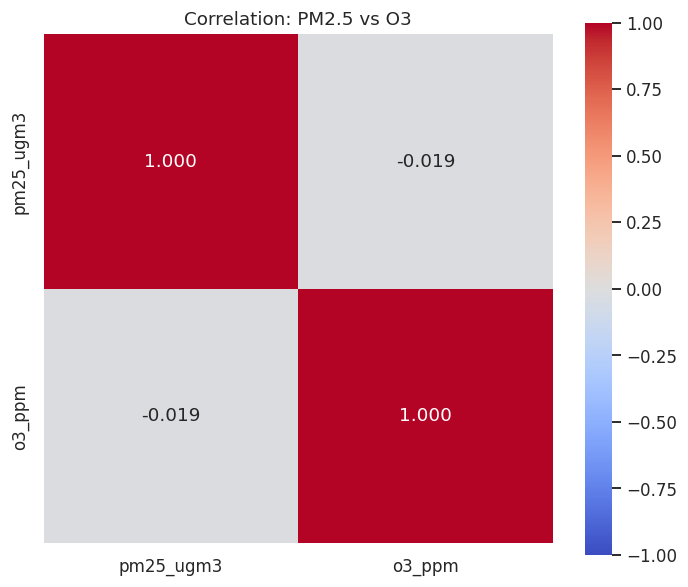

           pm25_ugm3    o3_ppm
pm25_ugm3   1.000000 -0.018601
o3_ppm     -0.018601  1.000000


In [29]:
plt.figure(figsize=(6.5, 5.5))
corr = wide_clean[['pm25_ugm3', 'o3_ppm']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation: PM2.5 vs O3')
plt.tight_layout()
plt.savefig('figs/05_corr_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()

print(corr)


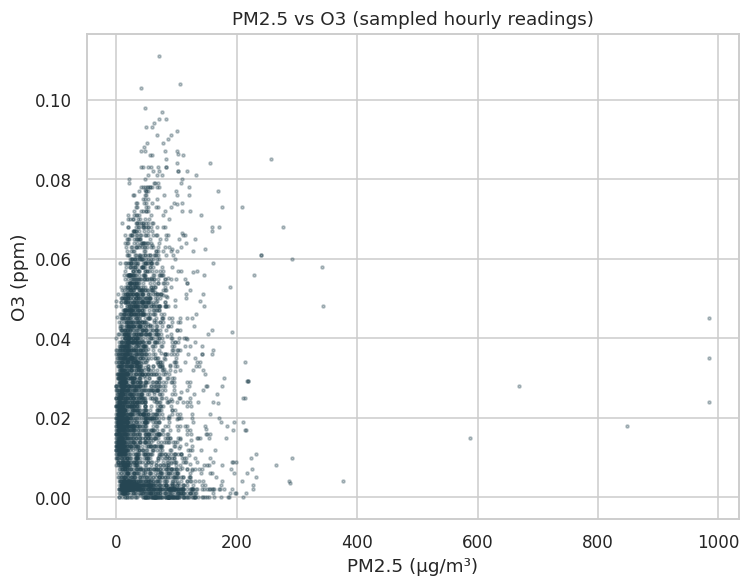

In [30]:
sample = wide_clean.dropna().sample(min(4000, wide_clean.dropna().shape[0]), random_state=42)
plt.figure(figsize=(7, 5.5))
plt.scatter(sample['pm25_ugm3'], sample['o3_ppm'], s=4, alpha=0.3, color='#264653')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('O3 (ppm)')
plt.title('PM2.5 vs O3 (sampled hourly readings)')
plt.tight_layout()
plt.savefig('figs/06_scatter_pm25_o3.png', dpi=140, bbox_inches='tight')
plt.show()


**Interpretation:** the weak/negative correlation is consistent with atmospheric chemistry — PM2.5 accumulates in the cool, stagnant winter air while O3 formation needs strong sunlight and warmer temperatures, so the two pollutants tend to peak in different seasons rather than together.


### 7.6 Year-over-year monthly average trend

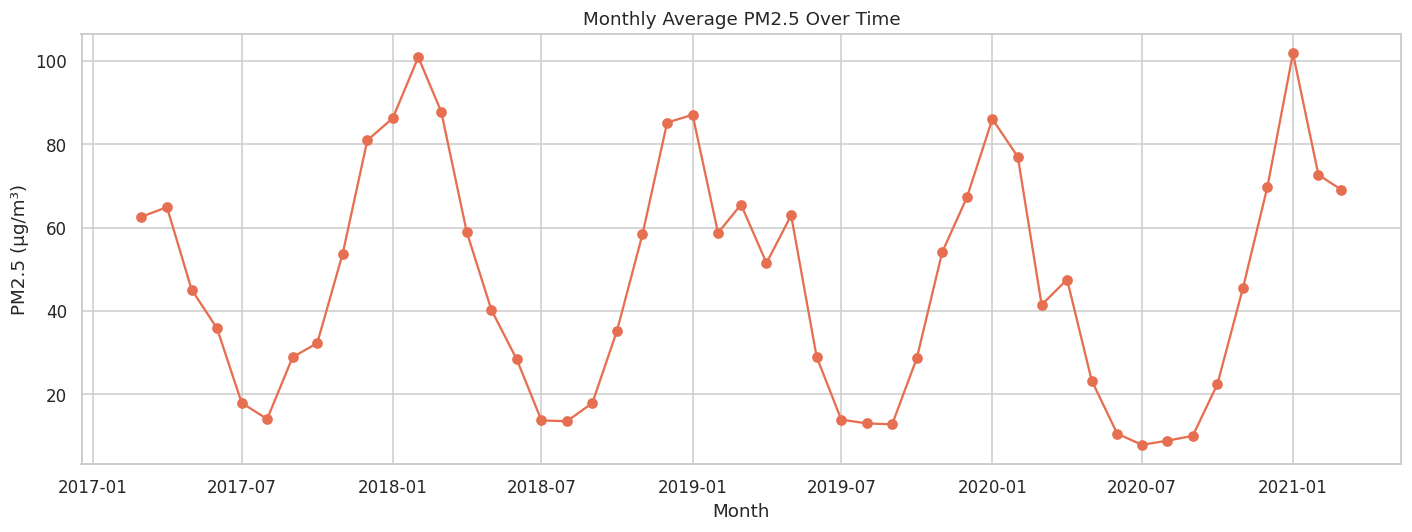

In [31]:
monthly_avg = wide_clean['pm25_ugm3'].resample('MS').mean()
plt.figure(figsize=(13, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='#e76f51')
plt.title('Monthly Average PM2.5 Over Time')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('figs/07_monthly_avg_trend.png', dpi=140, bbox_inches='tight')
plt.show()


### 7.7 Data availability over time

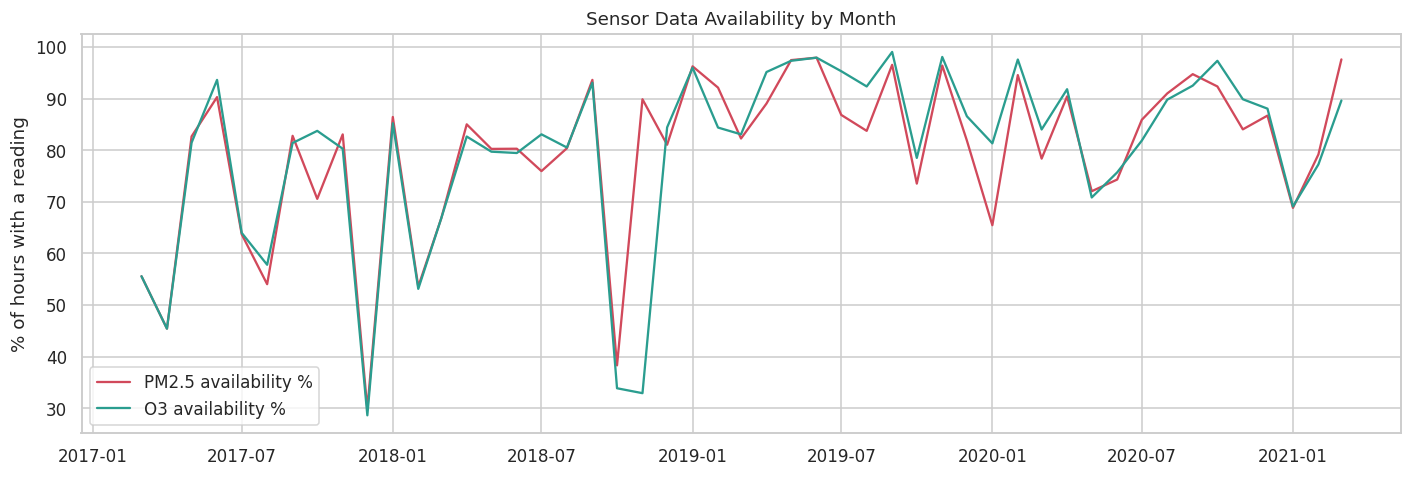

In [32]:
avail = wide_full.notna().resample('MS').mean() * 100
plt.figure(figsize=(13, 4.5))
plt.plot(avail.index, avail['pm25_ugm3'], label='PM2.5 availability %', color='#d1495b')
plt.plot(avail.index, avail['o3_ppm'], label='O3 availability %', color='#2a9d8f')
plt.ylabel('% of hours with a reading')
plt.title('Sensor Data Availability by Month')
plt.legend()
plt.tight_layout()
plt.savefig('figs/08_data_availability.png', dpi=140, bbox_inches='tight')
plt.show()


**Interpretation:** availability dips in some months indicate sensor maintenance/outage periods. This confirms the earlier decision to cap interpolation at 6 hours rather than filling multi-day sensor outages with fabricated values.


## 8. Feature Engineering

The upcoming neural network assignment will forecast PM2.5. We now build the calendar, lag, rolling-window and target features a sequence model (LSTM/GRU/1-D CNN) will need.


### 8.1 Calendar / cyclical time features

In [33]:
feat = wide_clean.copy()

feat['hour'] = feat.index.hour
feat['day'] = feat.index.day
feat['month'] = feat.index.month
feat['year'] = feat.index.year
feat['dayofweek'] = feat.index.dayofweek          # 0=Mon
feat['is_weekend'] = (feat['dayofweek'] >= 5).astype(int)

def month_to_season(m):
    if m in (12, 1, 2):
        return 'winter'
    elif m in (3, 4, 5):
        return 'pre_monsoon'
    elif m in (6, 7, 8, 9):
        return 'monsoon'
    else:
        return 'post_monsoon'

feat['season'] = feat['month'].apply(month_to_season)

# Cyclical encoding so the network sees hour 23 and hour 0 as "close" (important for RNNs/MLPs alike)
feat['hour_sin'] = np.sin(2 * np.pi * feat['hour'] / 24)
feat['hour_cos'] = np.cos(2 * np.pi * feat['hour'] / 24)
feat['month_sin'] = np.sin(2 * np.pi * feat['month'] / 12)
feat['month_cos'] = np.cos(2 * np.pi * feat['month'] / 12)

print(feat[['hour','dayofweek','is_weekend','season','hour_sin','hour_cos']].head().to_string())


                           hour  dayofweek  is_weekend       season  hour_sin      hour_cos
local                                                                                      
2017-03-03 05:00:00+05:45     5          4           0  pre_monsoon  0.965926  2.588190e-01
2017-03-03 06:00:00+05:45     6          4           0  pre_monsoon  1.000000  6.123234e-17
2017-03-03 07:00:00+05:45     7          4           0  pre_monsoon  0.965926 -2.588190e-01
2017-03-03 08:00:00+05:45     8          4           0  pre_monsoon  0.866025 -5.000000e-01
2017-03-03 09:00:00+05:45     9          4           0  pre_monsoon  0.707107 -7.071068e-01


### 8.2 Air Quality Index (AQI) category — a classification-ready target

Using the standard US EPA PM2.5 breakpoints, each hourly reading is labelled into an AQI category. This gives a second possible task (classification) alongside PM2.5 regression for the neural-network assignment.


In [34]:
def pm25_to_aqi_category(pm):
    if pd.isna(pm):
        return np.nan
    if pm <= 12.0:
        return 'Good'
    elif pm <= 35.4:
        return 'Moderate'
    elif pm <= 55.4:
        return 'Unhealthy for Sensitive Groups'
    elif pm <= 150.4:
        return 'Unhealthy'
    elif pm <= 250.4:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

feat['aqi_category'] = feat['pm25_ugm3'].apply(pm25_to_aqi_category)

order = ['Good','Moderate','Unhealthy for Sensitive Groups','Unhealthy','Very Unhealthy','Hazardous']
counts = feat['aqi_category'].value_counts().reindex(order)
print(counts)


aqi_category
Good                               5704
Moderate                          10345
Unhealthy for Sensitive Groups     6094
Unhealthy                          8354
Very Unhealthy                      604
Hazardous                           116
Name: count, dtype: int64


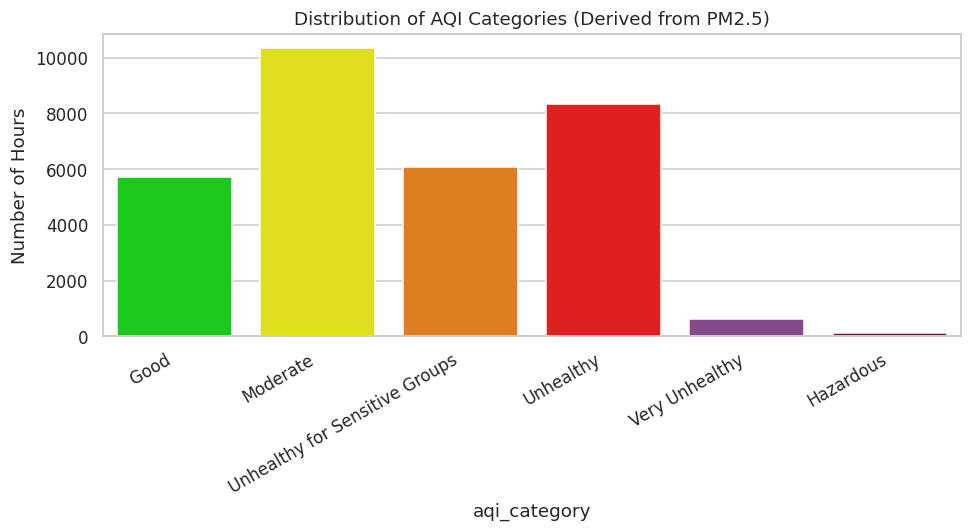

In [36]:
import os
os.makedirs("figs", exist_ok=True)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette=colors,
    legend=False
)

plt.xticks(rotation=30, ha='right')
plt.ylabel('Number of Hours')
plt.title('Distribution of AQI Categories (Derived from PM2.5)')

plt.tight_layout()
plt.savefig("figs/09_aqi_category_counts.png", dpi=140, bbox_inches="tight")
plt.show()


**Observation:** a large share of hours fall in the **Unhealthy** or worse categories, underscoring the severity of Kathmandu's air-quality problem and confirming this is a meaningful problem for a predictive model to address. The class imbalance visible here will need to be handled (e.g. class weighting) if AQI classification is chosen as the neural-network task.


### 8.3 Lag features (autoregressive signal for the sequence model)

In [37]:
for lag in [1, 2, 3, 6, 12, 24]:
    feat[f'pm25_lag_{lag}h'] = feat['pm25_ugm3'].shift(lag)
    feat[f'o3_lag_{lag}h'] = feat['o3_ppm'].shift(lag)

print(feat[['pm25_ugm3','pm25_lag_1h','pm25_lag_2h','pm25_lag_3h','pm25_lag_24h']].head(6).to_string())


                           pm25_ugm3  pm25_lag_1h  pm25_lag_2h  pm25_lag_3h  pm25_lag_24h
local                                                                                    
2017-03-03 05:00:00+05:45       54.5          NaN          NaN          NaN           NaN
2017-03-03 06:00:00+05:45       73.3         54.5          NaN          NaN           NaN
2017-03-03 07:00:00+05:45       76.1         73.3         54.5          NaN           NaN
2017-03-03 08:00:00+05:45       95.0         76.1         73.3         54.5           NaN
2017-03-03 09:00:00+05:45      208.5         95.0         76.1         73.3           NaN
2017-03-03 10:00:00+05:45      191.8        208.5         95.0         76.1           NaN


### 8.4 Rolling-window statistics

In [38]:
feat['pm25_roll_mean_3h'] = feat['pm25_ugm3'].rolling(3).mean()
feat['pm25_roll_std_3h']  = feat['pm25_ugm3'].rolling(3).std()
feat['pm25_roll_mean_24h'] = feat['pm25_ugm3'].rolling(24).mean()
feat['pm25_roll_std_24h']  = feat['pm25_ugm3'].rolling(24).std()

print(feat[['pm25_ugm3','pm25_roll_mean_3h','pm25_roll_std_3h','pm25_roll_mean_24h']].tail(6).to_string())


                           pm25_ugm3  pm25_roll_mean_3h  pm25_roll_std_3h  pm25_roll_mean_24h
local                                                                                        
2021-03-12 19:00:00+05:45       48.0          45.000000          3.605551           93.875000
2021-03-12 20:00:00+05:45       51.0          48.333333          2.516611           91.625000
2021-03-12 21:00:00+05:45       50.0          49.666667          1.527525           89.458333
2021-03-12 22:00:00+05:45       45.0          48.666667          3.214550           87.041667
2021-03-12 23:00:00+05:45       46.0          47.000000          2.645751           82.958333
2021-03-13 00:00:00+05:45       50.0          47.000000          2.645751           76.916667


### 8.5 Forecasting target

For the neural network assignment, the natural target is **PM2.5 one step (1 hour) ahead**, i.e. `y(t) = pm25(t+1)`. We create it here and drop the rows that lag/lead creation leaves incomplete.


In [39]:
feat['pm25_target_next_1h'] = feat['pm25_ugm3'].shift(-1)

before = feat.shape[0]
feat_model = feat.dropna().copy()
after = feat_model.shape[0]
print(f"Rows before dropping NaN (from lag/rolling/target creation): {before}")
print(f"Rows after dropping NaN: {after}  ({100*after/before:.1f}% retained)")
print()
print("Final engineered feature columns:")
print(list(feat_model.columns))


Rows before dropping NaN (from lag/rolling/target creation): 35300
Rows after dropping NaN: 28672  (81.2% retained)

Final engineered feature columns:
['o3_ppm', 'pm25_ugm3', 'hour', 'day', 'month', 'year', 'dayofweek', 'is_weekend', 'season', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'aqi_category', 'pm25_lag_1h', 'o3_lag_1h', 'pm25_lag_2h', 'o3_lag_2h', 'pm25_lag_3h', 'o3_lag_3h', 'pm25_lag_6h', 'o3_lag_6h', 'pm25_lag_12h', 'o3_lag_12h', 'pm25_lag_24h', 'o3_lag_24h', 'pm25_roll_mean_3h', 'pm25_roll_std_3h', 'pm25_roll_mean_24h', 'pm25_roll_std_24h', 'pm25_target_next_1h']


### 8.6 Correlation of engineered features with the forecasting target

In [40]:
num_cols = feat_model.select_dtypes(include=[np.number]).columns
corr_target = feat_model[num_cols].corr()['pm25_target_next_1h'].sort_values(ascending=False)
print(corr_target.round(3).to_string())


pm25_target_next_1h    1.000
pm25_roll_mean_3h      0.641
pm25_ugm3              0.640
pm25_roll_mean_24h     0.601
pm25_lag_1h            0.545
pm25_lag_2h            0.468
pm25_lag_24h           0.442
pm25_lag_12h           0.419
pm25_lag_3h            0.418
month_sin              0.378
pm25_lag_6h            0.343
month_cos              0.329
pm25_roll_std_24h      0.276
pm25_roll_std_3h       0.202
hour_sin               0.084
o3_lag_12h             0.040
o3_lag_6h              0.026
year                   0.026
hour                   0.006
day                   -0.012
hour_cos              -0.026
dayofweek             -0.032
is_weekend            -0.036
o3_lag_24h            -0.044
o3_lag_3h             -0.057
o3_ppm                -0.059
o3_lag_2h             -0.078
o3_lag_1h             -0.081
month                 -0.244


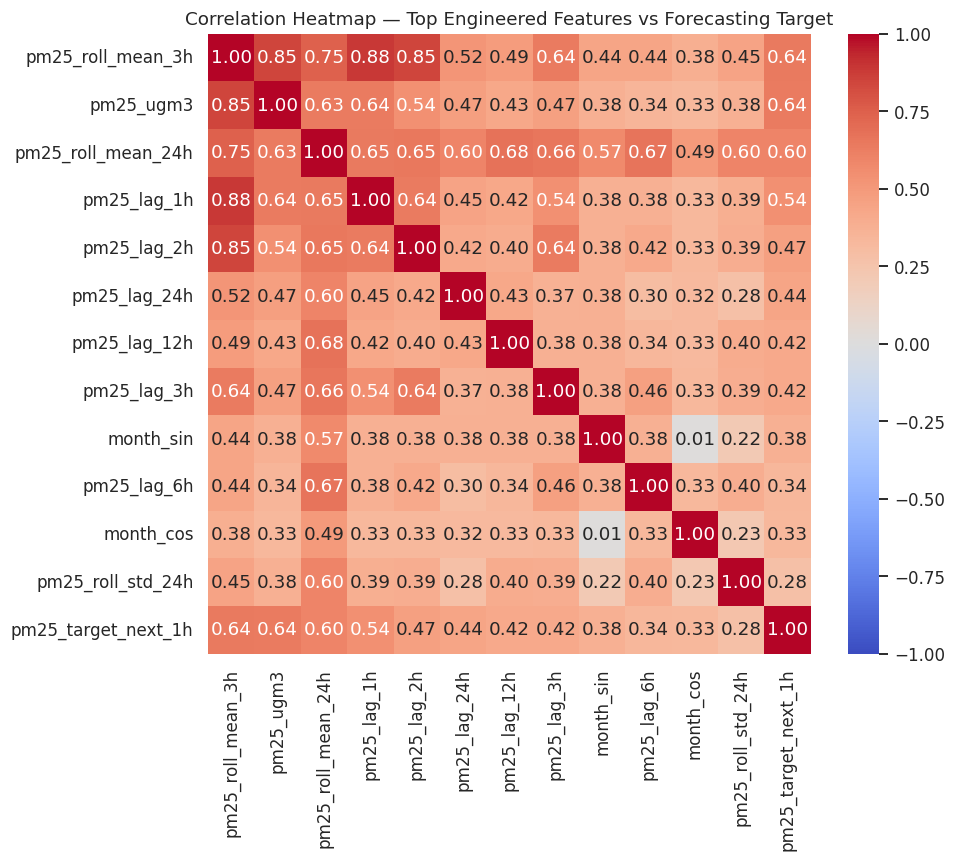

In [41]:
top_feats = corr_target.drop('pm25_target_next_1h').abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(9, 8))
sns.heatmap(feat_model[list(top_feats) + ['pm25_target_next_1h']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Top Engineered Features vs Forecasting Target')
plt.tight_layout()
plt.savefig('figs/10_feature_target_corr.png', dpi=140, bbox_inches='tight')
plt.show()


**Interpretation:** as expected for a highly autocorrelated pollutant time series, the most predictive features are the **short-horizon lags and rolling means of PM2.5 itself** (`pm25_lag_1h`, `pm25_roll_mean_3h`, …), confirming that a sequence model that can exploit recent history (LSTM/GRU) is well suited to this forecasting task.


## 9. Train / Validation / Test Split and Scaling

Because this is a time series, we use a **chronological split** (not random shuffling) so that the model is always evaluated on data that comes *after* what it was trained on — exactly how it will be used in the next assignment for forecasting.


In [42]:
n = len(feat_model)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = feat_model.iloc[:train_end]
val_df   = feat_model.iloc[train_end:val_end]
test_df  = feat_model.iloc[val_end:]

print(f"Train: {train_df.shape[0]} rows  ({train_df.index.min()} -> {train_df.index.max()})")
print(f"Val:   {val_df.shape[0]} rows  ({val_df.index.min()} -> {val_df.index.max()})")
print(f"Test:  {test_df.shape[0]} rows  ({test_df.index.min()} -> {test_df.index.max()})")


Train: 20070 rows  (2017-03-04 05:00:00+05:45 -> 2020-01-14 00:00:00+05:45)
Val:   4301 rows  (2020-01-14 01:00:00+05:45 -> 2020-08-15 19:00:00+05:45)
Test:  4301 rows  (2020-08-15 20:00:00+05:45 -> 2021-03-12 23:00:00+05:45)


In [43]:
feature_cols = [c for c in feat_model.columns
                if c not in ['aqi_category', 'season', 'pm25_target_next_1h']]
target_col = 'pm25_target_next_1h'

# One-hot encode the remaining categorical columns (season) for the scaler/model
train_enc = pd.get_dummies(train_df[feature_cols + ['season']], columns=['season'])
val_enc   = pd.get_dummies(val_df[feature_cols + ['season']],   columns=['season'])
test_enc  = pd.get_dummies(test_df[feature_cols + ['season']],  columns=['season'])

# Align columns (in case a season is missing from a split)
val_enc = val_enc.reindex(columns=train_enc.columns, fill_value=0)
test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(train_enc), columns=train_enc.columns, index=train_enc.index)
X_val_scaled   = pd.DataFrame(scaler.transform(val_enc), columns=val_enc.columns, index=val_enc.index)
X_test_scaled  = pd.DataFrame(scaler.transform(test_enc), columns=test_enc.columns, index=test_enc.index)

y_train, y_val, y_test = train_df[target_col], val_df[target_col], test_df[target_col]

print("Scaled feature matrix shapes:")
print("X_train:", X_train_scaled.shape, "| X_val:", X_val_scaled.shape, "| X_test:", X_test_scaled.shape)
print()
print(X_train_scaled.head(3).to_string())


Scaled feature matrix shapes:
X_train: (20070, 32) | X_val: (4301, 32) | X_test: (4301, 32)

                             o3_ppm  pm25_ugm3      hour  day     month  year  dayofweek  is_weekend  hour_sin  hour_cos  month_sin  month_cos  pm25_lag_1h  o3_lag_1h  pm25_lag_2h  o3_lag_2h  pm25_lag_3h  o3_lag_3h  pm25_lag_6h  o3_lag_6h  pm25_lag_12h  o3_lag_12h  pm25_lag_24h  o3_lag_24h  pm25_roll_mean_3h  pm25_roll_std_3h  pm25_roll_mean_24h  pm25_roll_std_24h  season_monsoon  season_post_monsoon  season_pre_monsoon  season_winter
local                                                                                                                                                                                                                                                                                                                                                                                                                                                 
2017-03-04 05:00:00+05:45  0.

**Notes for the next assignment:**
- The scaler (`MinMaxScaler`) is **fit only on the training split** and reused (`.transform`) on validation/test, which avoids data leakage from the future into training.
- `X_*_scaled` are ready to be reshaped into `(samples, timesteps, features)` 3-D tensors for an LSTM/GRU, or used directly as flat vectors for an MLP baseline.
- `y_train`, `y_val`, `y_test` hold the regression target (`pm25` one hour ahead); `aqi_category` (dropped from `X` above but still present in `train_df`/`val_df`/`test_df`) is retained for an alternative classification framing.


## 10. Saving the Processed Dataset

The cleaned, feature-engineered dataset is exported so it can be loaded directly in the neural-network implementation assignment.


In [45]:
feat_model.to_csv('kathmandu_air_quality_features.csv')
X_train_scaled.assign(**{target_col: y_train}).to_csv('train_scaled.csv')
X_val_scaled.assign(**{target_col: y_val}).to_csv('val_scaled.csv')
X_test_scaled.assign(**{target_col: y_test}).to_csv('test_scaled.csv')


## 11. Summary of Findings

- The raw OpenAQ export (60,779 long-format rows) contained **no NaNs, but did contain a hidden data-quality problem**: 4,676 readings used the sentinel codes `-999` µg/m³ / `-0.999` ppm to mean "no valid reading", and a further 230 readings were small negative calibration-noise values. Both were fixed (sentinels → NaN, small negatives → clipped to 0) **before** any statistic or plot was produced.
- The cleaned data was reshaped into an **hourly wide-format time series** of PM2.5 (µg/m³) and O3 (ppm) spanning **March 2017 – March 2021**, covering **84.7% of all possible hourly slots**; short gaps (≤ 6h) were interpolated and longer sensor outages were left as missing rather than fabricated.
- **PM2.5 is strongly right-skewed and highly seasonal**, peaking in the dry winter months (Nov–Feb) and dropping sharply during the monsoon (Jun–Sep); it also shows a clear **diurnal double-peak** (morning and evening rush hours).
- **O3 behaves oppositely** to PM2.5 across the season, consistent with photochemical formation needing strong sunlight, and the two pollutants show a **weak negative correlation**.
- Using EPA PM2.5 breakpoints, roughly **49% of all hours** fall into "Unhealthy for Sensitive Groups" or worse AQI categories, motivating a forecasting model that can give advance warning of pollution spikes.
- **Feature engineering** produced: cyclical hour/month encodings, weekend/season indicators, an AQI category label, **lag features up to 24h**, and **3h/24h rolling mean & std**, all of which correlate strongly with the 1-hour-ahead PM2.5 forecasting target — confirming that a **sequence model (LSTM/GRU)** should perform well.
- Data was **chronologically split** (70/15/15 train/val/test) and scaled with a **train-fit MinMaxScaler**, ready to be reshaped into 3-D tensors for the neural network in the next assignment

